In [ ]:
from flower_model._kmeans import _spherical_kmeans
from flower_model.external._gabor_like_filters import _gabor_like_filters
from flower_model._filterbank import _shift_filters
import torch
import matplotlib.pyplot as plt

In [ ]:
N = 31
sigma = 20.
k = 8
SPH_KMEANS_ITERS = 100
device='cuda'

filters = _gabor_like_filters(N, sigma)
print(filters.shape)

(1281, 31, 31)


In [43]:
filters = filters.astype("complex64")
filters = torch.tensor(filters, device=device)

In [44]:
filter_list = []
filter_list.append(filters[1])
filter_list.append(filters[1280])
filters = torch.stack(filter_list)
print(filters.shape)

torch.Size([2, 31, 31])


In [45]:
filters = _shift_filters(filters, 2, 16)
print(filters.shape)

torch.Size([32, 34, 34])


In [46]:
abs_filters = torch.abs(filters)

filter_amount = filters.size(dim=0)
abs_filters = abs_filters.view(filter_amount, -1)

In [47]:
labels = _spherical_kmeans(k, abs_filters, SPH_KMEANS_ITERS)

In [48]:
filters = filters.cpu()
labels = labels.cpu()

In [49]:
# for i in range(0,filters.size(dim=0),57):
#     plt.imshow(filters[i].imag)
#     plt.show()

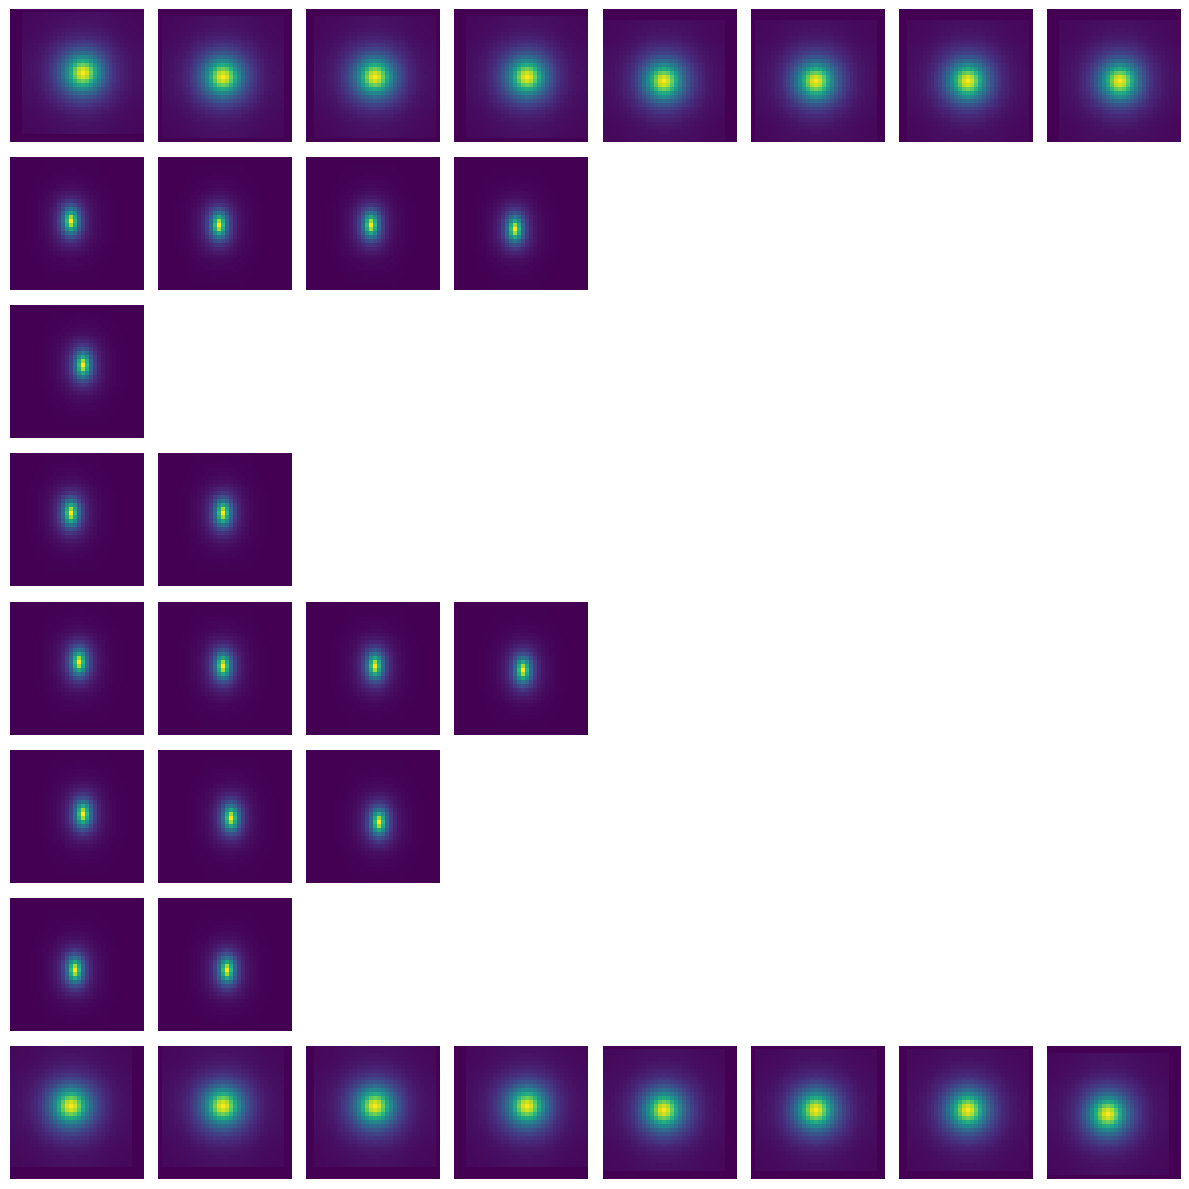

In [50]:
max_cluster_size = max((labels == c).sum().item() for c in range(k))

fig, axes = plt.subplots(k, max_cluster_size, figsize=(max_cluster_size * 1.5, k * 1.5))

for cluster in range(k):
    filters_in_cluster = filters[labels == cluster]
    cluster_size = filters_in_cluster.size(dim=0)
    for i in range(max_cluster_size):
        ax = axes[cluster, i]
        if i < cluster_size:
            ax.imshow(filters_in_cluster[i].abs(), cmap="viridis")
        ax.axis("off")

plt.tight_layout()
plt.show()